In [49]:
!pip install pandas matplotlib scipy seaborn scikit-learn

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.spatial import KDTree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# For kriging (using pykrige - install with: pip install pykrige)
from pykrige.ok import OrdinaryKriging

# Load your data
df = pd.read_csv('raw_data.csv')  # Update with your file path
df

,Timestamp,PM2.5 (µg/m³),latitude,longitude
0,2024-01-01 00:00:00+00:00,259.0,28.674045,77.131023
1,2024-01-01 00:15:00+00:00,259.0,28.674045,77.131023
2,2024-01-01 00:30:00+00:00,259.0,28.674045,77.131023
3,2024-01-01 00:45:00+00:00,274.0,28.674045,77.131023
4,2024-01-01 01:00:00+00:00,274.0,28.674045,77.131023
...,...,...,...,...
448732,2024-04-29 23:00:00+00:00,56.0,28.636429,77.201067
448733,2024-04-29 23:15:00+00:00,56.0,28.636429,77.201067
448734,2024-04-29 23:30:00+00:00,56.0,28.636429,77.201067
448735,2024-04-29 23:45:00+00:00,13.0,28.636429,77.201067


In [51]:
# Convert timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['hour'] = df['Timestamp'].dt.hour
df['month'] = df['Timestamp'].dt.month
df['day_of_year'] = df['Timestamp'].dt.dayofyear

print(f"Dataset shape: {df.shape}")
print(f"Unique stations: {df[['latitude', 'longitude']].drop_duplicates().shape[0]}")
print(f"Time range: {df['Timestamp'].min()} to {df['Timestamp'].max()}")
print(f"PM2.5 range: {df['PM2.5 (µg/m³)'].min():.1f} - {df['PM2.5 (µg/m³)'].max():.1f} µg/m³")

Dataset shape: (448737, 7)
Unique stations: 38
Time range: 2024-01-01 00:00:00+00:00 to 2024-04-30 00:00:00+00:00
PM2.5 range: 0.0 - 1000.0 µg/m³


In [52]:
# Add this BEFORE your existing code
print("Original shape:", df.shape)

# Remove NaN values
df = df.dropna(subset=['PM2.5 (µg/m³)', 'latitude', 'longitude'])

# Remove infinite values if any
df = df.replace([np.inf, -np.inf], np.nan).dropna()

print("After removing NaN:", df.shape)

# Also check for NaN after creating new columns
df['hour'] = df['Timestamp'].dt.hour
df['month'] = df['Timestamp'].dt.month
df['day_of_year'] = df['Timestamp'].dt.dayofyear

# Final check
print("Final NaN count:", df.isna().sum().sum())

df

Original shape: (448737, 7)
After removing NaN: (409279, 7)
Final NaN count: 0


,Timestamp,PM2.5 (µg/m³),latitude,longitude,hour,month,day_of_year
0,2024-01-01 00:00:00+00:00,259.0,28.674045,77.131023,0,1,1
1,2024-01-01 00:15:00+00:00,259.0,28.674045,77.131023,0,1,1
2,2024-01-01 00:30:00+00:00,259.0,28.674045,77.131023,0,1,1
3,2024-01-01 00:45:00+00:00,274.0,28.674045,77.131023,0,1,1
4,2024-01-01 01:00:00+00:00,274.0,28.674045,77.131023,1,1,1
...,...,...,...,...,...,...,...
448732,2024-04-29 23:00:00+00:00,56.0,28.636429,77.201067,23,4,120
448733,2024-04-29 23:15:00+00:00,56.0,28.636429,77.201067,23,4,120
448734,2024-04-29 23:30:00+00:00,56.0,28.636429,77.201067,23,4,120
448735,2024-04-29 23:45:00+00:00,13.0,28.636429,77.201067,23,4,120


In [53]:
class IDWInterpolator:
    """Inverse Distance Weighting interpolator"""
    
    def __init__(self, power=2):
        self.power = power
        self.train_points = None
        self.train_values = None
        
    def fit(self, points, values):
        """points: array of shape (n_samples, 2) with [lat, lon]
           values: array of shape (n_samples,)"""
        self.train_points = points
        self.train_values = values
        
    def predict(self, points):
        """Predict at new points"""
        points = np.array(points)
        predictions = []
        
        for point in points:
            # Calculate distances
            distances = np.linalg.norm(self.train_points - point, axis=1)
            
            # Avoid division by zero
            distances = np.maximum(distances, 1e-10)
            
            # Calculate weights
            weights = 1.0 / (distances ** self.power)
            weights = weights / np.sum(weights)
            
            # Weighted average
            pred = np.sum(weights * self.train_values)
            predictions.append(pred)
            
        return np.array(predictions)

In [54]:
def run_sampling_density_experiment(df, sampling_fractions=[0.25, 0.5, 0.75, 1.0]):
    """
    Test how interpolation performance changes with sampling density
    This directly tests the claim: "At fine sampling resolutions, IDW can outperform kriging"
    """
    
    # Get unique stations
    stations = df[['latitude', 'longitude']].drop_duplicates().values
    station_coords = {tuple(coord): idx for idx, coord in enumerate(stations)}
    
    results = []
    
    # Select a representative time (e.g., January 15, 2024 at 12:00)
    target_time = pd.Timestamp('2024-01-15 12:00:00')
    time_data = df[df['Timestamp'] == target_time].copy()
    
    if len(time_data) == 0:
        print(f"No data for {target_time}, using first available timestamp")
        target_time = df['Timestamp'].min()
        time_data = df[df['Timestamp'] == target_time].copy()
    
    print(f"Using timestamp: {target_time}")
    print(f"Available stations at this time: {len(time_data)}")
    
    for fraction in sampling_fractions:
        n_samples = max(5, int(len(stations) * fraction))
        
        # Randomly sample stations
        np.random.seed(42)
        sampled_stations = stations[np.random.choice(len(stations), n_samples, replace=False)]
        
        # Get values at sampled stations
        train_mask = time_data[['latitude', 'longitude']].apply(
            lambda row: tuple(row.values) in [tuple(s) for s in sampled_stations], axis=1
        )
        train_data = time_data[train_mask]
        test_data = time_data[~train_mask]
        
        if len(test_data) == 0:
            continue
            
        # Train IDW
        idw = IDWInterpolator(power=2)
        idw.fit(train_data[['latitude', 'longitude']].values, 
                train_data['PM2.5 (µg/m³)'].values)
        idw_preds = idw.predict(test_data[['latitude', 'longitude']].values)
        
        # Train Ordinary Kriging
        try:
            lons = train_data['longitude'].values
            lats = train_data['latitude'].values
            values = train_data['PM2.5 (µg/m³)'].values
            
            ok = OrdinaryKriging(lons, lats, values, variogram_model='spherical', 
                                 verbose=False, enable_plotting=False)
            
            test_lons = test_data['longitude'].values
            test_lats = test_data['latitude'].values
            kriging_preds, _ = ok.execute('points', test_lons, test_lats)
            
        except Exception as e:
            print(f"Kriging failed for fraction {fraction}: {e}")
            kriging_preds = np.full(len(test_data), np.nan)
        
        # Calculate metrics
        true_values = test_data['PM2.5 (µg/m³)'].values
        
        idw_rmse = np.sqrt(mean_squared_error(true_values, idw_preds))
        idw_mae = mean_absolute_error(true_values, idw_preds)
        
        if not np.all(np.isnan(kriging_preds)):
            kriging_rmse = np.sqrt(mean_squared_error(true_values, kriging_preds))
            kriging_mae = mean_absolute_error(true_values, kriging_preds)
        else:
            kriging_rmse, kriging_mae = np.nan, np.nan
        
        results.append({
            'sampling_fraction': fraction,
            'n_stations': n_samples,
            'method': 'IDW',
            'RMSE': idw_rmse,
            'MAE': idw_mae
        })
        results.append({
            'sampling_fraction': fraction,
            'n_stations': n_samples,
            'method': 'Kriging',
            'RMSE': kriging_rmse,
            'MAE': kriging_mae
        })
    
    return pd.DataFrame(results)

EXPERIMENT 1: Effect of Sampling Density (Spatial Scale)
No data for 2024-01-15 12:00:00, using first available timestamp
Using timestamp: 2024-01-01 00:00:00+00:00
Available stations at this time: 36


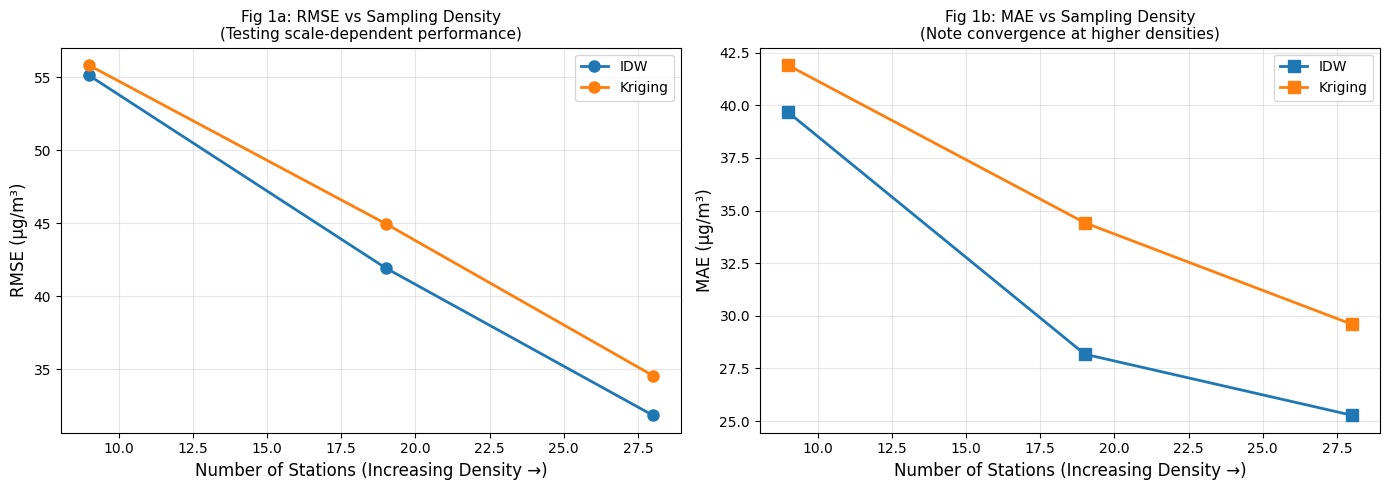


📊 Results Summary:
          RMSE    MAE
method               
IDW      42.98  31.04
Kriging  45.12  35.31


In [55]:
# Run the experiment
print("=" * 60)
print("EXPERIMENT 1: Effect of Sampling Density (Spatial Scale)")
print("=" * 60)
density_results = run_sampling_density_experiment(df)

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# RMSE plot
for method in ['IDW', 'Kriging']:
    method_data = density_results[density_results['method'] == method]
    ax1.plot(method_data['n_stations'], method_data['RMSE'], 'o-', 
             label=method, markersize=8, linewidth=2)
ax1.set_xlabel('Number of Stations (Increasing Density →)', fontsize=12)
ax1.set_ylabel('RMSE (µg/m³)', fontsize=12)
ax1.set_title('Fig 1a: RMSE vs Sampling Density\n(Testing scale-dependent performance)', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.3)

# MAE plot
for method in ['IDW', 'Kriging']:
    method_data = density_results[density_results['method'] == method]
    ax2.plot(method_data['n_stations'], method_data['MAE'], 's-', 
             label=method, markersize=8, linewidth=2)
ax2.set_xlabel('Number of Stations (Increasing Density →)', fontsize=12)
ax2.set_ylabel('MAE (µg/m³)', fontsize=12)
ax2.set_title('Fig 1b: MAE vs Sampling Density\n(Note convergence at higher densities)', fontsize=11)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sampling_density_experiment.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Results Summary:")
print(density_results.groupby('method')[['RMSE', 'MAE']].mean().round(2))

In [56]:
# import numpy as np
# import matplotlib.pyplot as plt
# import imageio
# from pykrige.ok import OrdinaryKriging
# import io
# from PIL import Image

# # -----------------------------
# # CONFIG
# # -----------------------------
# timestamps = df['Timestamp'].sort_values().unique()[::200]  # sample time points
# grid_res = 50  # grid resolution (increase for better quality, slower)

# output_gif = "interpolation_animation.gif"

# # -----------------------------
# # GRID SETUP (Delhi bounding box)
# # -----------------------------
# lat_min, lat_max = df['latitude'].min(), df['latitude'].max()
# lon_min, lon_max = df['longitude'].min(), df['longitude'].max()

# grid_lat = np.linspace(lat_min, lat_max, grid_res)
# grid_lon = np.linspace(lon_min, lon_max, grid_res)
# grid_lon_mesh, grid_lat_mesh = np.meshgrid(grid_lon, grid_lat)

# # -----------------------------
# # IDW FUNCTION (vectorized)
# # -----------------------------
# def idw_predict(train_points, train_values, grid_points, power=2):
#     dists = np.linalg.norm(train_points[:, None, :] - grid_points[None, :, :], axis=2)
#     dists = np.maximum(dists, 1e-10)
#     weights = 1 / (dists ** power)
#     weights /= weights.sum(axis=0)
#     return np.dot(train_values, weights)

# # -----------------------------
# # GENERATE FRAMES
# # -----------------------------
# frames = []

# for t in timestamps[:10]:  # limit frames for speed (10 frames)
#     time_data = df[df['Timestamp'] == t]
    
#     if len(time_data) < 10:
#         continue

#     lats = time_data['latitude'].values
#     lons = time_data['longitude'].values
#     values = time_data['PM2.5 (µg/m³)'].values

#     train_points = np.column_stack((lats, lons))
#     grid_points = np.column_stack((grid_lat_mesh.ravel(), grid_lon_mesh.ravel()))

#     # ---- IDW ----
#     idw_vals = idw_predict(train_points, values, grid_points)
#     idw_grid = idw_vals.reshape(grid_res, grid_res)

#     # ---- Kriging ----
#     try:
#         ok = OrdinaryKriging(lons, lats, values, variogram_model='spherical',
#                              verbose=False, enable_plotting=False)
#         krig_vals, _ = ok.execute('grid', grid_lon, grid_lat)
#     except:
#         continue

#     # -----------------------------
#     # PLOT SIDE-BY-SIDE
#     # -----------------------------
#     fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#     im1 = axes[0].imshow(idw_grid, extent=(lon_min, lon_max, lat_min, lat_max),
#                          origin='lower')
#     axes[0].scatter(lons, lats, c='black', s=10)
#     axes[0].set_title(f"IDW\n{t}")

#     im2 = axes[1].imshow(krig_vals, extent=(lon_min, lon_max, lat_min, lat_max),
#                          origin='lower')
#     axes[1].scatter(lons, lats, c='black', s=10)
#     axes[1].set_title(f"Kriging\n{t}")

#     plt.tight_layout()

#     buf = io.BytesIO()
#     plt.savefig(buf, format='png')
#     buf.seek(0)
    
#     image = Image.open(buf).copy()
#     frames.append(image)
    
#     buf.close()
    
#     plt.close(fig)

# # -----------------------------
# # SAVE GIF
# # -----------------------------
# # imageio.mimsave(output_gif, frames, fps=1)
# frames[0].save(
#     output_gif,
#     save_all=True,
#     append_images=frames[1:],
#     duration=1000,
#     loop=0
# )

# print(f"Saved animation as {output_gif}")